<a href="https://colab.research.google.com/github/ayeshaazahidd0-stack/Digital-Image-Processing/blob/main/Lab3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import cv2, numpy as np
from google.colab.patches import cv2_imshow
from google.colab import files
import matplotlib.pyplot as plt

Upload image A (for MASKING)


Saving pngtree-traffic-light-png-image_19390337.png to pngtree-traffic-light-png-image_19390337.png
Loaded for MASKING: pngtree-traffic-light-png-image_19390337.png (2500, 2500, 3)


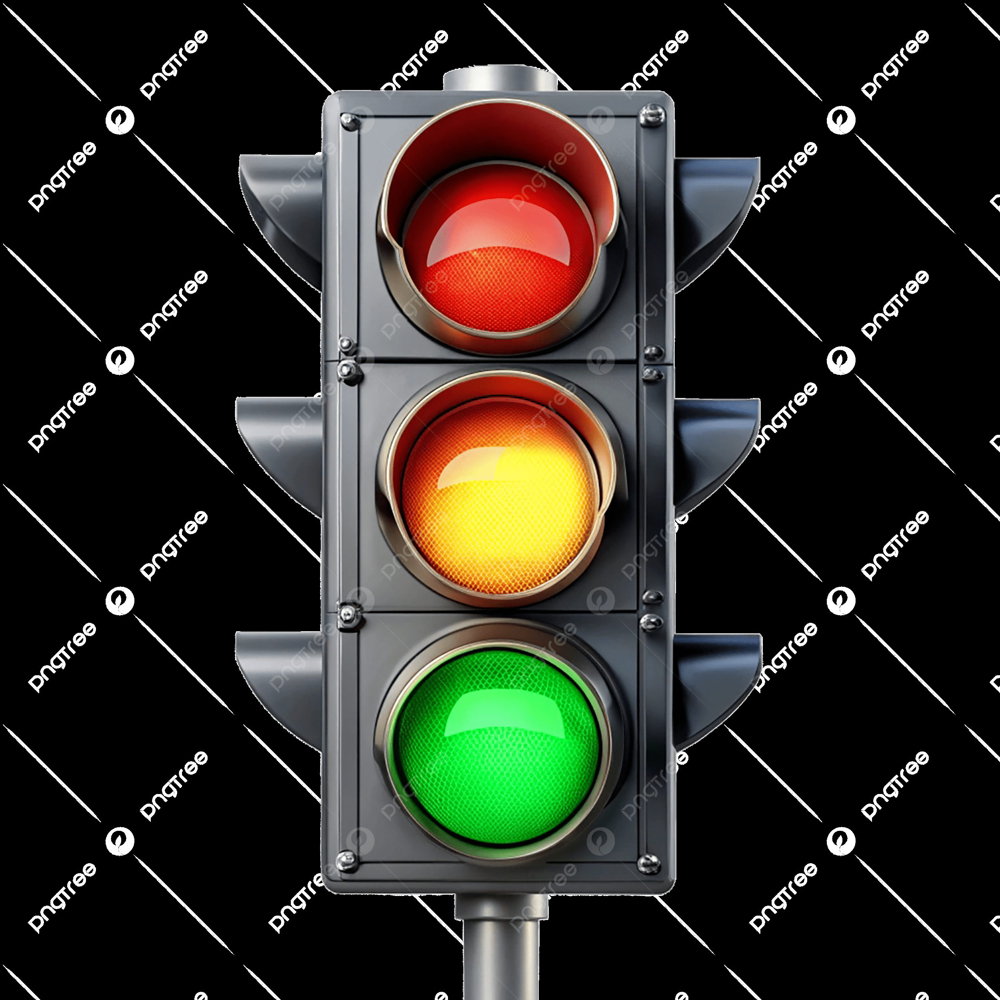

In [4]:
#upload ONE image for Masking (Image A) - choose a colorful photo
print ("Upload image A (for MASKING)")
uploaded = files.upload()
fnameA = list(uploaded.keys())[0]
img_mask_bgr = cv2.imread(fnameA)
print("Loaded for MASKING:", fnameA, img_mask_bgr.shape)
cv2_imshow(img_mask_bgr)

**Part A — Masking — use Image A**

**Task 1 — Scenario: “I only want to work with colors easily.”**

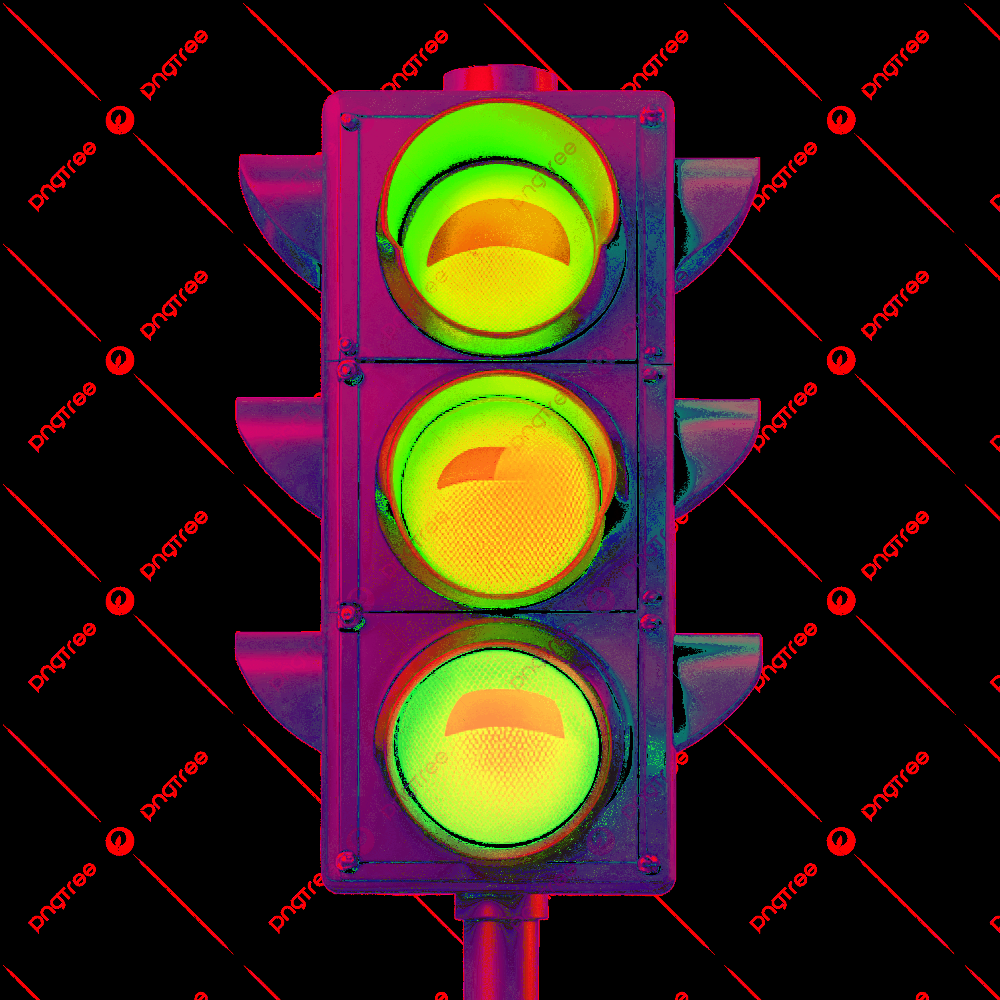

In [5]:
#Convert Image A from BGR to HSV ( good  for color-based masks)
hsvA = cv2.cvtColor(img_mask_bgr, cv2.COLOR_BGR2HSV)
cv2_imshow(hsvA) #just to seee something is produced

Upload Image B ( for INTENSITY TRANSFORMATIONS)


Saving images.jpg to images.jpg
Loaded for INTENSITY: images.jpg (530, 350, 3)


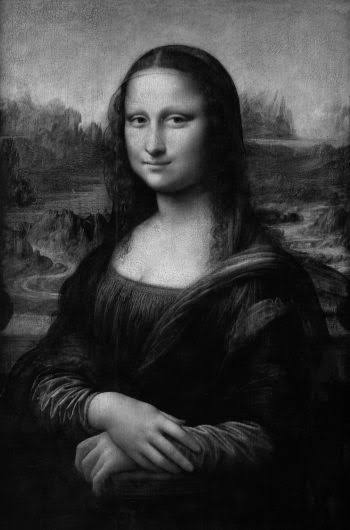

In [6]:
#Upload a DIFFERENT image for INTENSITY (Image B) | With both dark & bright areas
print("Upload Image B ( for INTENSITY TRANSFORMATIONS)")
uploaded = files.upload()
fnameB = list(uploaded.keys())[0]
img_tone_bgr = cv2.imread(fnameB)
print("Loaded for INTENSITY:", fnameB, img_tone_bgr.shape)
cv2_imshow(img_tone_bgr)


**Task 2 — Scenario: “Find red things in the picture**

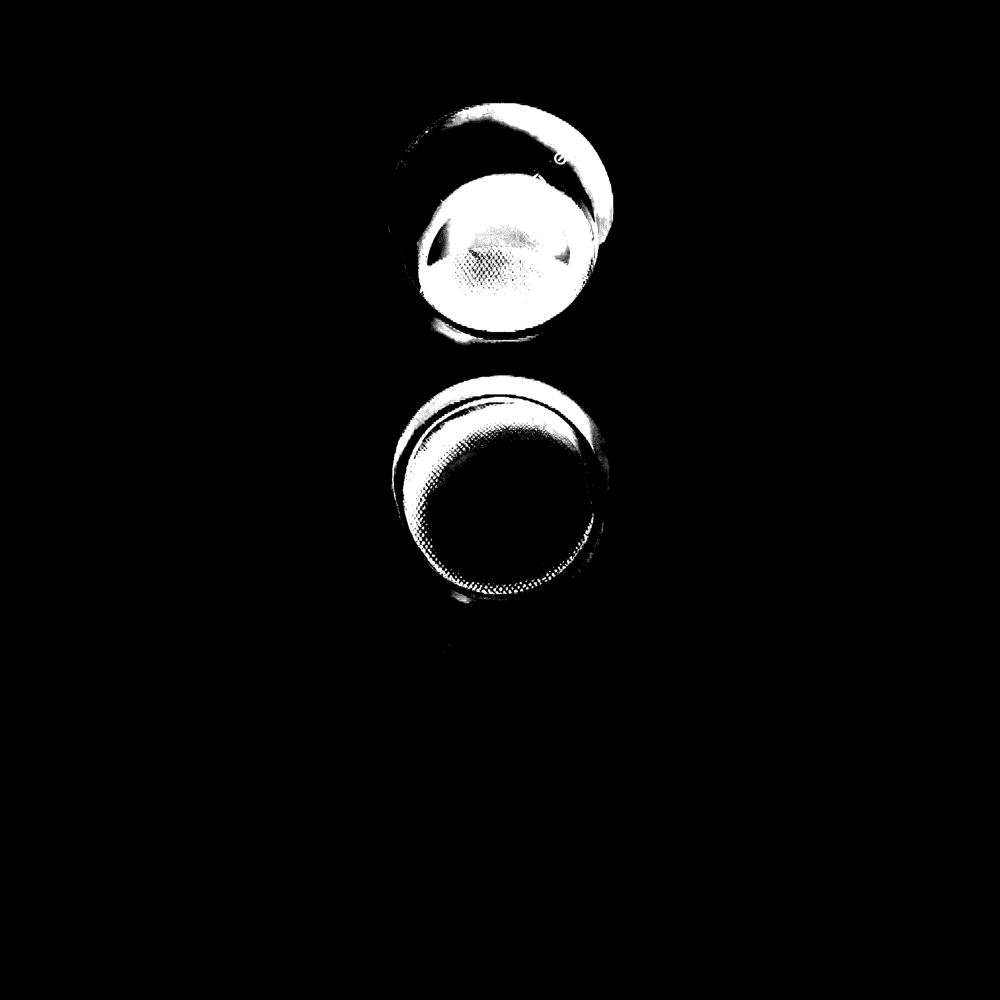

In [7]:
# Simple red range (lower reds)
lower_red = np.array([0, 100, 100])

upper_red = np.array([10, 255, 255])
mask_red = cv2.inRange(hsvA, lower_red, upper_red)
cv2_imshow(mask_red)

**Task 3 — Scenario: “Show only the red objects, hide the rest.”**

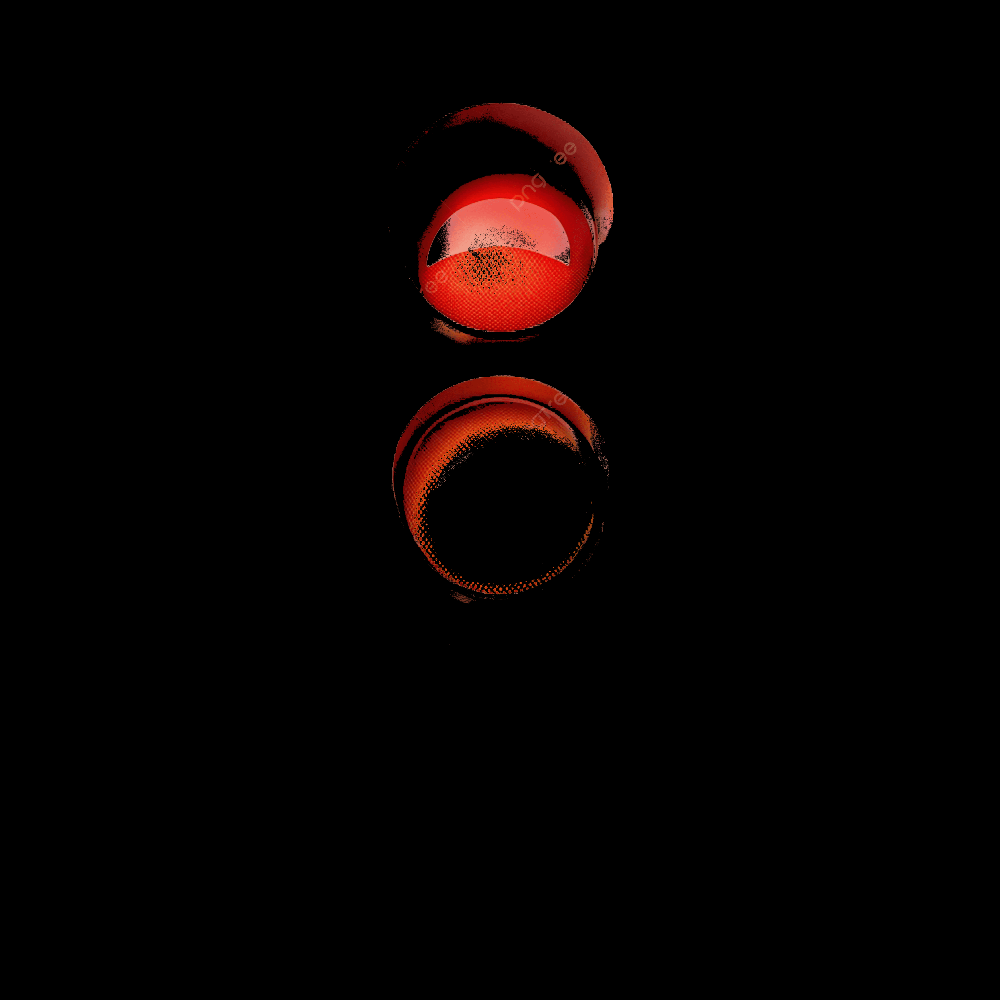

In [8]:
# Keep only red parts of the image using the mask
red_only = cv2.bitwise_and(img_mask_bgr, img_mask_bgr, mask=mask_red)
cv2_imshow(red_only)

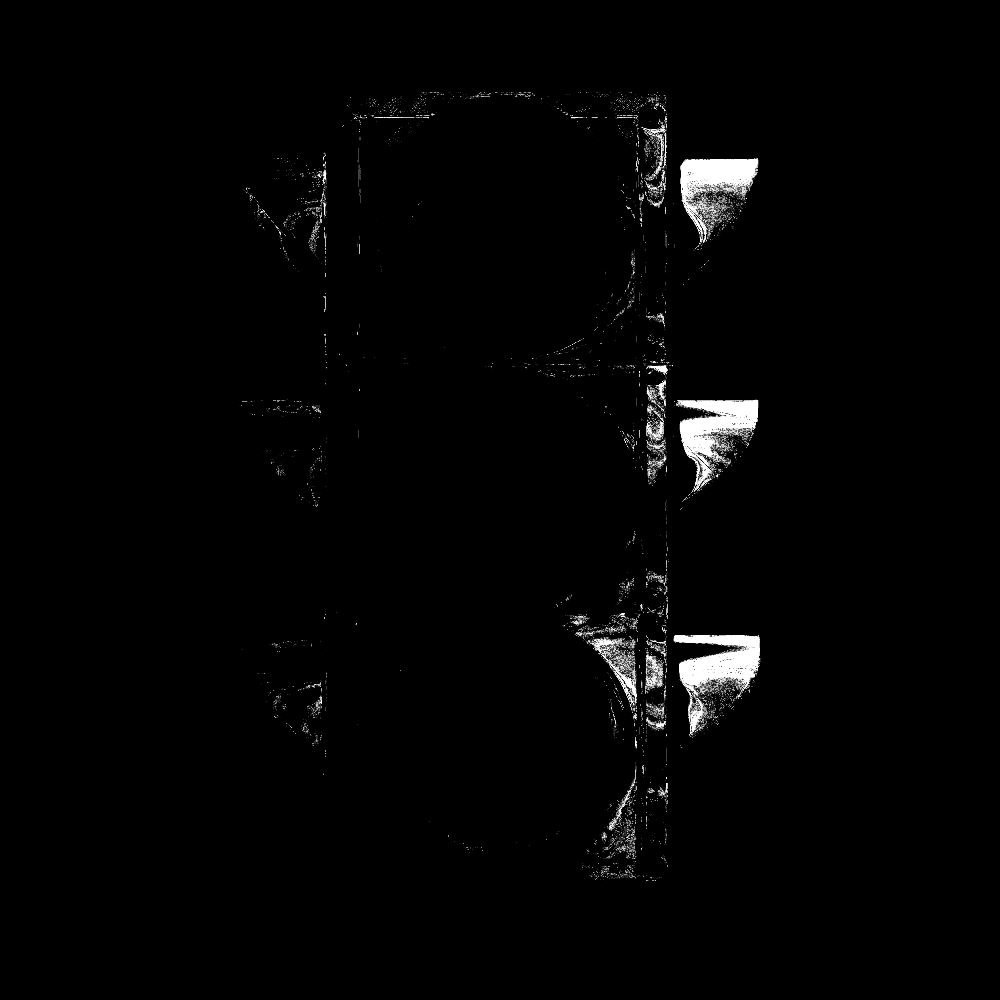

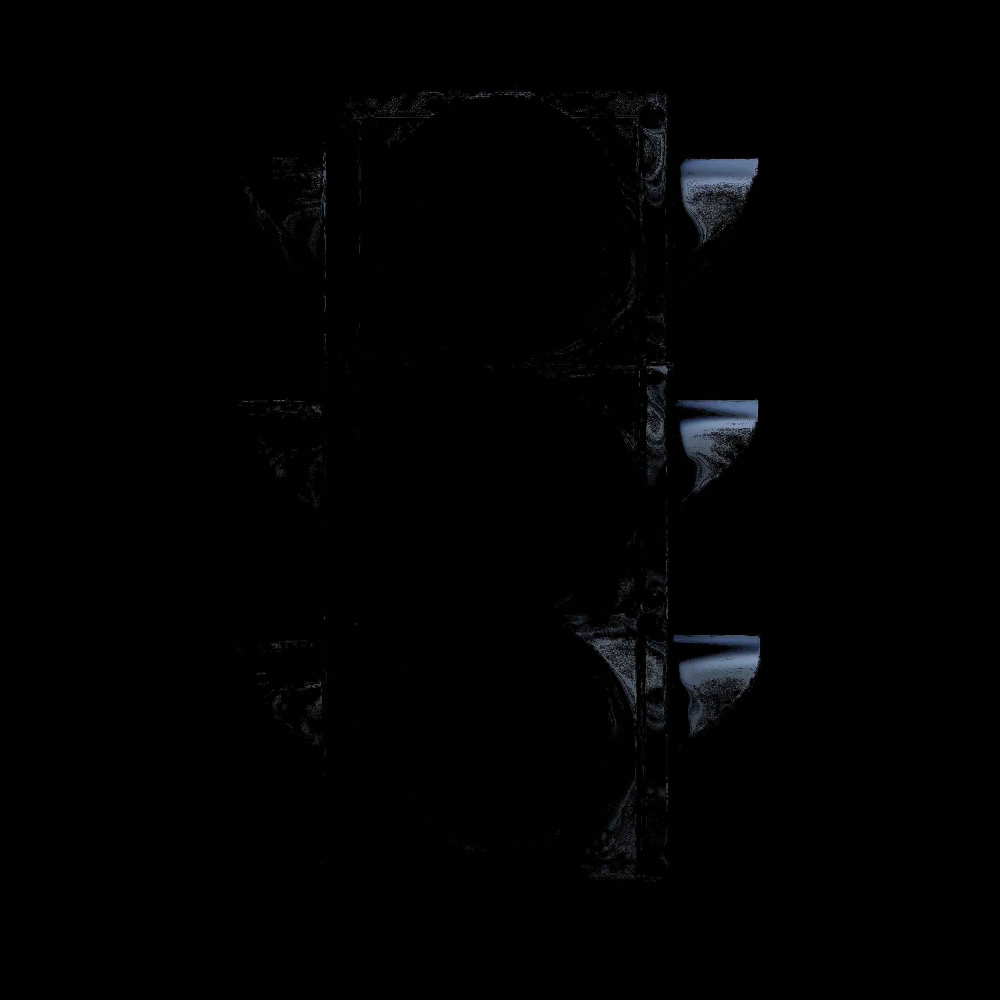

In [9]:
# make a blue mask (works on hsvA)

lower_blue = np.array([70, 50, 50]) # H,S,V mins
upper_blue = np.array([130, 255, 255]) # H,S,V max
mask_blue = cv2.inRange(hsvA, lower_blue, upper_blue)
cv2_imshow(mask_blue) # white = blue pixels
# keep only the blue parts
blue_only = cv2.bitwise_and(img_mask_bgr, img_mask_bgr, mask=mask_blue)
cv2_imshow(blue_only)

**Task 4 — Scenario: “Hide red objects; show everything else.”**

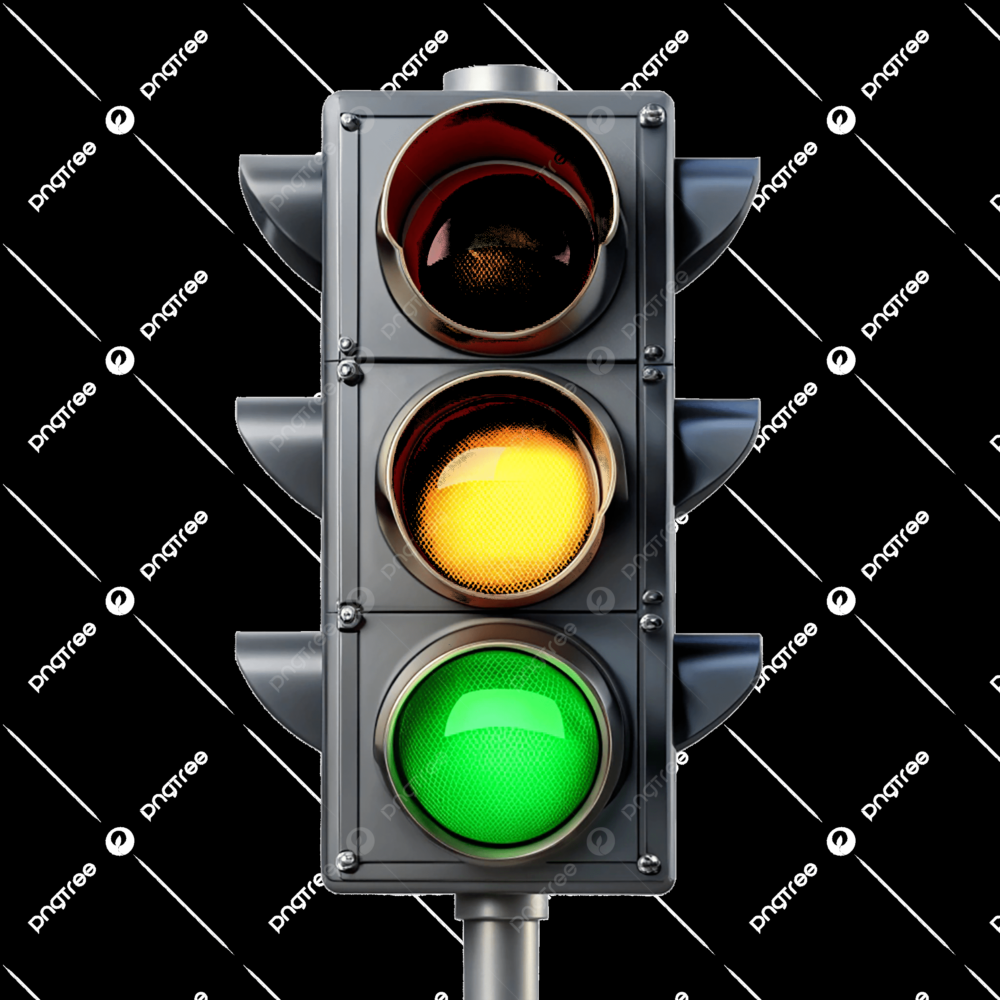

In [10]:
# Invert the mask to remove red parts
inverse_red = cv2.bitwise_not(mask_red)
no_red = cv2.bitwise_and(img_mask_bgr, img_mask_bgr, mask=inverse_red)
cv2_imshow(no_red)

**Part B — Intensity Transformations (Week 3) — use Image B**

In [11]:
# Convert Image B to grayscale (used in all tasks below)
grayB = cv2.cvtColor(img_tone_bgr, cv2.COLOR_BGR2GRAY)

**Task 6 — Scenario: “Create a photo negative for a cool effect.”**

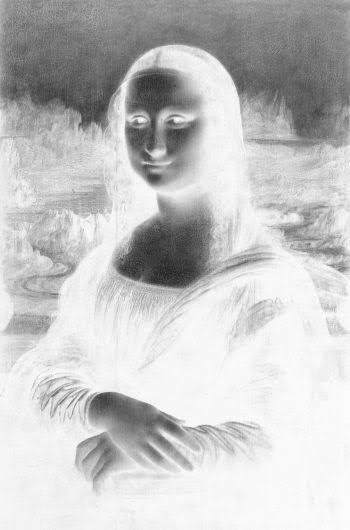

In [20]:
negativeB = 255 - grayB
cv2_imshow(negativeB)

**Task 7 — Scenario: “Check one pixel to see the math.”**

In [25]:
y, x = 66, 69 # you can pick any location
print("Original:", grayB[y, x], "| Negative:", negativeB[y, x])

Original: 153 | Negative: 102


**Task 8 — Scenario: “Quick visual compare: original vs negative.”**

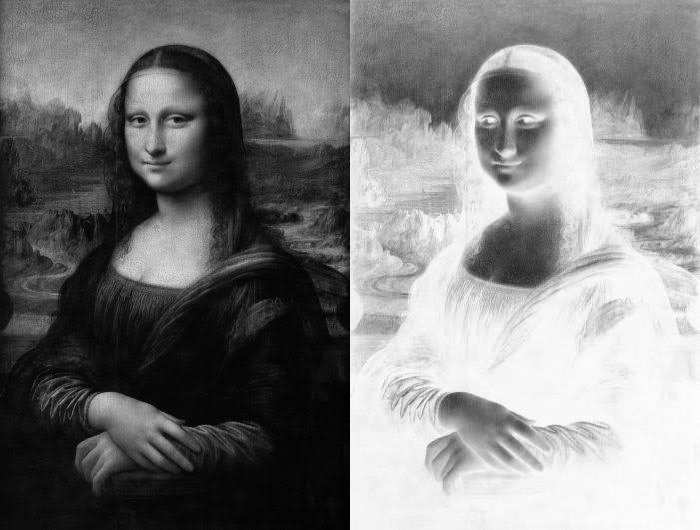

In [26]:
stack_neg = np.hstack([grayB, negativeB]) # put images side-by-side
cv2_imshow(stack_neg)

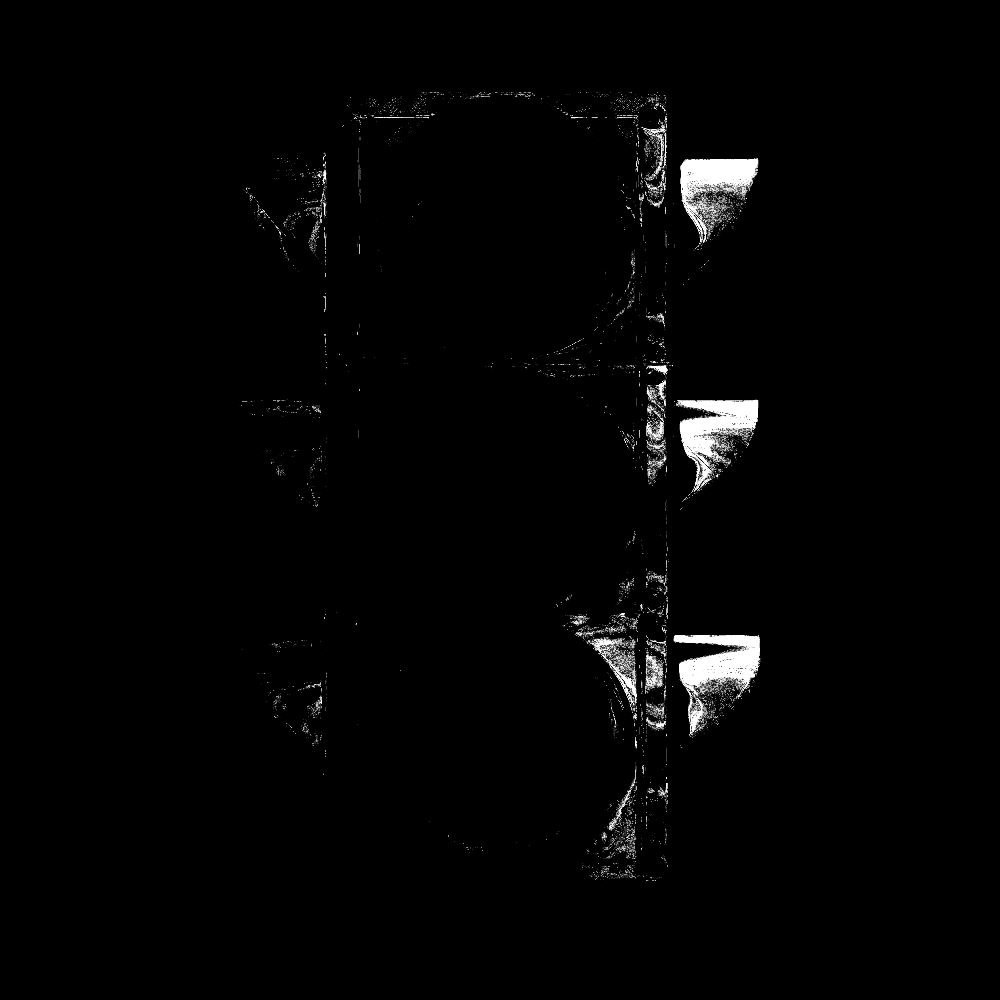

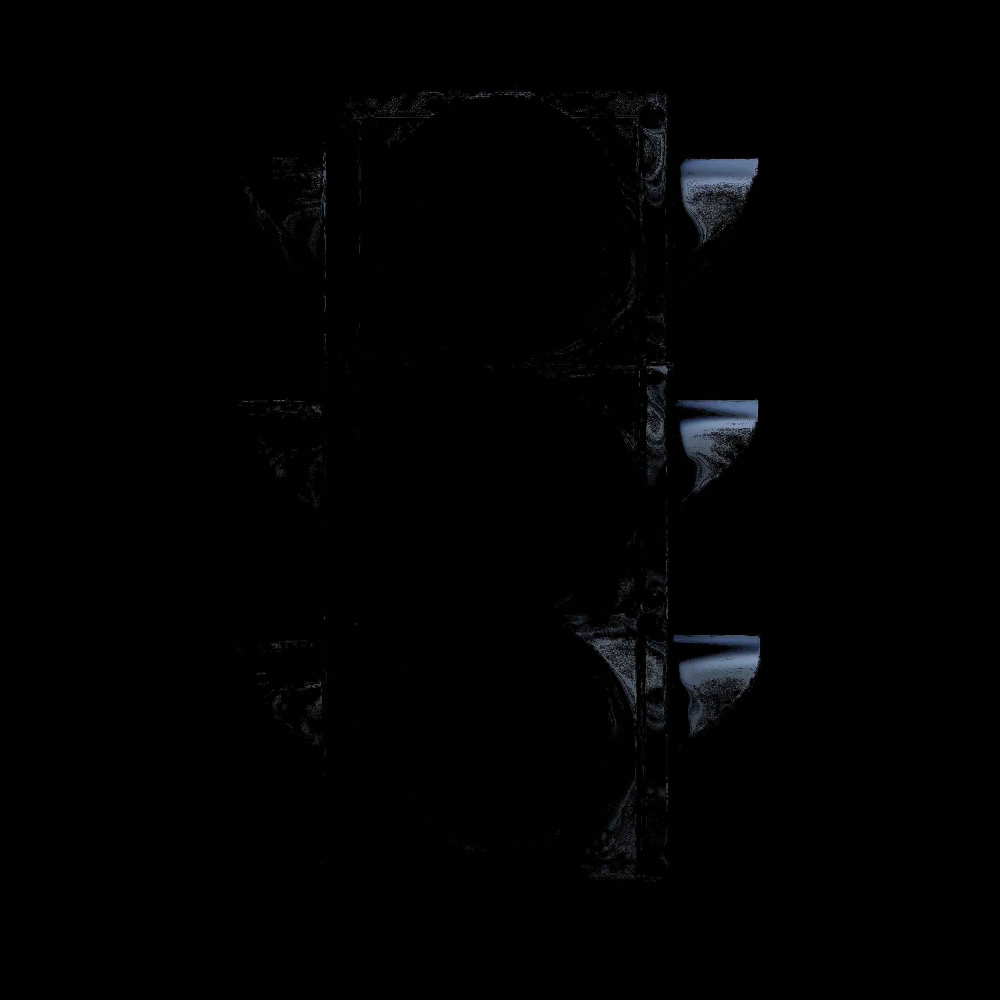

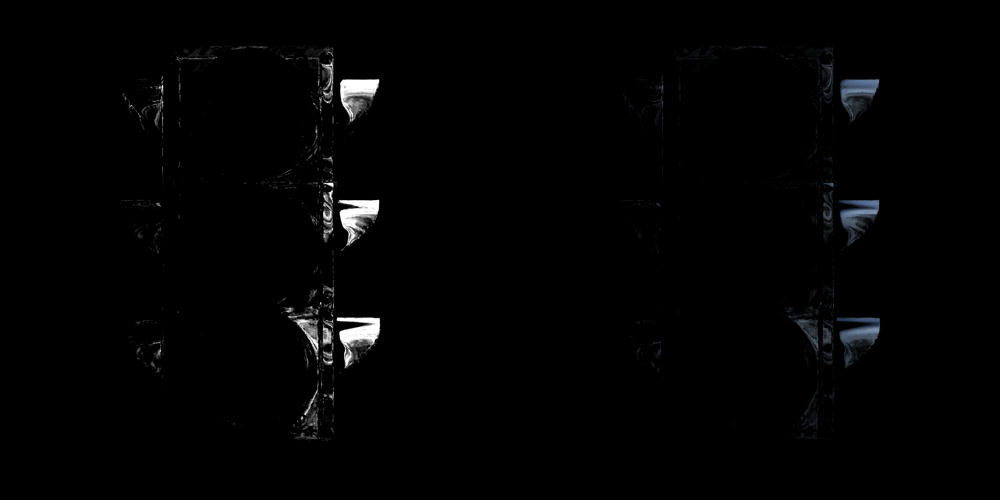

In [32]:
#make a blue mask ( works on hsvA)
lower_blue = np.array([70, 50, 50]) # H,S,V mins
upper_blue = np.array([130, 255, 255]) # H,S,V max
mask_blue = cv2.inRange(hsvA, lower_blue, upper_blue)
cv2_imshow(mask_blue) # white = blue pixels

#keep only the blue parts
blue_only = cv2.bitwise_and(img_mask_bgr, img_mask_bgr, mask=mask_blue)
cv2_imshow(blue_only)

# Convert 2D mask to 3D BGR to match dimensions for stacking
mask_blue_bgr = cv2.cvtColor(mask_blue, cv2.COLOR_GRAY2BGR)
stack_neg = np.hstack([mask_blue_bgr, blue_only]) # put images side-by-side
cv2_imshow(stack_neg)

**Task 9 — Scenario: “Bright areas are fine; dark areas lack detail. Boost the darks.”**

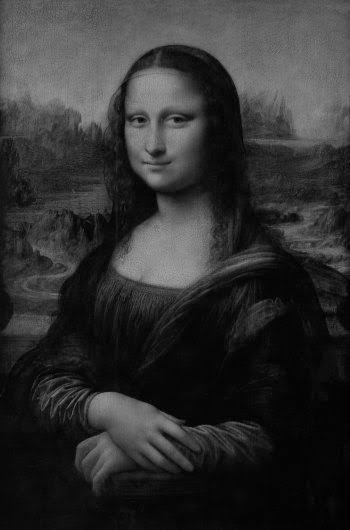

In [16]:
grayB_f = grayB.astype(np.float32) / 255.0 # scale to [0..1]
logB = np.log1p(grayB_f) * 255.0 # log(1+x) is safe at 0
logB = np.uint8(np.clip(logB, 0, 255))
cv2_imshow(logB)

**Task 10 — Scenario: “Show the exact change on one pixel (log).”**

In [17]:
print("Original:", grayB[y, x],"| Log:", logB[y, x])

Original: 150 | Log: 117


**Task 11 — Scenario: “Make the log effect a bit stronger.”**

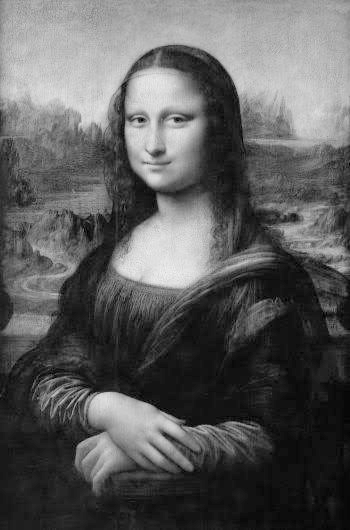

In [18]:
k = 5.0 # try 3, 5, or 8
logB_strong = (np.log1p(k * grayB_f) / np.log1p(k)) * 255.0
logB_strong = np.uint8(np.clip(logB_strong, 0, 255))
cv2_imshow(logB_strong)

**Task 12 — Scenario: “Compare original vs log (side-by-side).”**

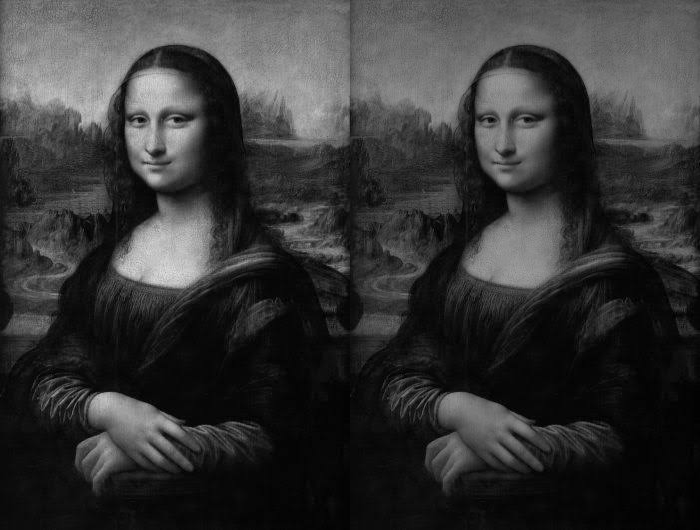

In [19]:
stack_log = np.hstack([grayB, logB])
cv2_imshow(stack_log)

**Task 13 — Scenario: “My photo is too dark—gently brighten it (gamma < 1).”**

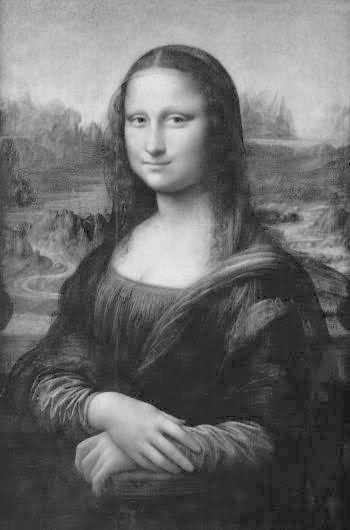

In [21]:
gamma = 0.5
gammaB_05 = np.uint8(np.clip(255.0 * (grayB_f ** gamma), 0, 255))
cv2_imshow(gammaB_05)

**Task 14 — Scenario: “My photo is too bright—gently darken it (gamma > 1).”**

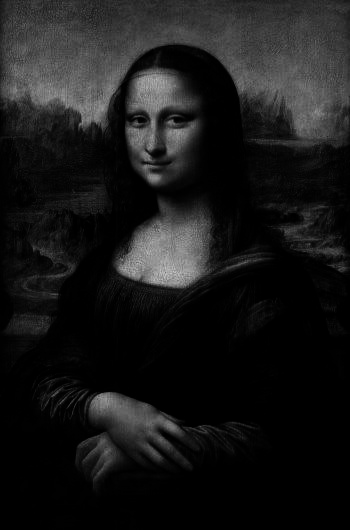

In [22]:
gamma = 2.0
gammaB_20 = np.uint8(np.clip(255.0 * (grayB_f ** gamma), 0, 255))

cv2_imshow(gammaB_20)

**Task 15 — Scenario: “Try a few gamma values and pick your favorite.”**

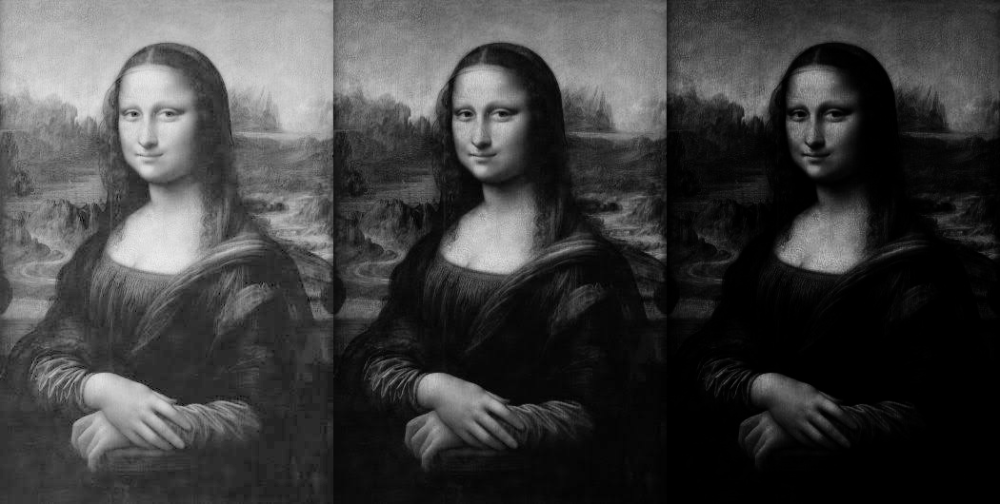

In [23]:
gammas = [0.5, 1.0, 2.0]
imgs = [np.uint8(255.0 * (grayB_f ** g)) for g in gammas]
panel = np.hstack(imgs) # 0.5 | 1.0 | 2.0
cv2_imshow(panel)

**Task 16 — Scenario: “Check exact numbers for gamma brightening.”**

In [24]:
print("Original:", grayB[y, x], "| Gamma(0.5):", imgs[0][y, x])

Original: 150 | Gamma(0.5): 195
